In [1]:
!pip install "https://github.com/Dao-AILab/flash-attention/releases/download/v2.8.3/flash_attn-2.8.3%2Bcu12torch2.9cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.8/253.8 MB 7.1 MB/s eta 0:00:00


In [2]:
print("Flash Attention installed successfully.")

Flash Attention installed successfully.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import itertools
from flash_attn import flash_attn_varlen_func, flash_attn_with_kvcache

class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-6, bias=False):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None

    def forward(self, x):
        input_dtype = x.dtype
        x = x.to(torch.float32)
        variance = x.pow(2).mean(dim=-1, keepdim=True)
        norm_x = x * torch.rsqrt(variance + self.eps)
        norm_x = norm_x * self.scale
        if self.shift is not None:
            norm_x = norm_x + self.shift
        return norm_x.to(input_dtype)

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], bias=False, dtype=cfg["dtype"])
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], bias=False, dtype=cfg["dtype"])
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], bias=False, dtype=cfg["dtype"])

    def forward(self, x):
        return self.fc3(F.silu(self.fc1(x)) * self.fc2(x))

def apply_rope(x, cos, sin):
    d = x.shape[-1]
    x1, x2 = x[..., : d // 2], x[..., d // 2 :]
    return torch.cat((x1 * cos - x2 * sin, x1 * sin + x2 * cos), dim=-1)

class GroupedQueryAttention(nn.Module):
    def __init__(self, layer_idx, cfg):
        super().__init__()
        self.layer_idx = layer_idx
        self.num_heads = cfg["n_heads"]
        self.num_kv_groups = cfg["n_kv_groups"]
        self.head_dim = cfg["head_dim"]

        self.W_query = nn.Linear(cfg["emb_dim"], self.num_heads * self.head_dim, bias=False, dtype=cfg["dtype"])
        self.W_key = nn.Linear(cfg["emb_dim"],   self.num_kv_groups * self.head_dim, bias=False, dtype=cfg["dtype"])
        self.W_value = nn.Linear(cfg["emb_dim"],  self.num_kv_groups * self.head_dim, bias=False, dtype=cfg["dtype"])
        self.out_proj = nn.Linear(self.num_heads * self.head_dim, cfg["emb_dim"], bias=False, dtype=cfg["dtype"])

        self.q_norm = RMSNorm(self.head_dim) if cfg.get("qk_norm") else None
        self.k_norm = RMSNorm(self.head_dim) if cfg.get("qk_norm") else None

    def forward(self, x, k_cache, v_cache, metadata):
        q = self.W_query(x).view(-1, self.num_heads, self.head_dim)
        k = self.W_key(x).view(-1, self.num_kv_groups, self.head_dim)
        v = self.W_value(x).view(-1, self.num_kv_groups, self.head_dim)

        if self.q_norm:
            q, k = self.q_norm(q), self.k_norm(k)

        q = apply_rope(q, metadata["cos"], metadata["sin"])
        k = apply_rope(k, metadata["cos"], metadata["sin"])

        if metadata["is_decoding"]:
            attn_out = flash_attn_with_kvcache(
                q.unsqueeze(1), k_cache, v_cache,
                k=k.unsqueeze(1),
                v=v.unsqueeze(1),
                cache_seqlens=metadata["seqlens"],
                block_table=metadata["block_table"],
                causal=True
            )
        else:
            slots = metadata["slot_mapping"]
            b_idx = slots // metadata["block_size"]
            o_idx = slots % metadata["block_size"]

            k_cache[b_idx, o_idx] = k
            v_cache[b_idx, o_idx] = v
            attn_out = flash_attn_varlen_func(
                q, k_cache, v_cache,
                cu_seqlens_q=metadata["cu_seqlens_q"],
                cu_seqlens_k=metadata["cu_seqlens_k"],
                max_seqlen_q=metadata["max_seqlen_q"],
                max_seqlen_k=metadata["max_seqlen_k"],
                causal=True,
                block_table=metadata["block_table"]
            )

        return self.out_proj(attn_out.view(-1, self.num_heads * self.head_dim))

class TransformerBlock(nn.Module):
    def __init__(self, cfg, layer_idx):
        super().__init__()
        self.att = GroupedQueryAttention(layer_idx, cfg)
        self.ff = FeedForward(cfg)
        self.norm1, self.norm2 = RMSNorm(cfg["emb_dim"]), RMSNorm(cfg["emb_dim"])

    def forward(self, x, k_cache, v_cache, metadata):
        x = x + self.att(self.norm1(x), k_cache, v_cache, metadata)
        x = x + self.ff(self.norm2(x))
        return x

class Qwen3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])
        self.trf_blocks = nn.ModuleList([TransformerBlock(cfg, i) for i in range(cfg["n_layers"])])
        self.final_norm = RMSNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        inv_freq = 1.0 / (cfg["rope_base"] ** (torch.arange(0, cfg["head_dim"], 2).float() / cfg["head_dim"]))
        t = torch.arange(cfg["context_length"]).float()
        freqs = torch.einsum("i,j->ij", t, inv_freq)
        self.register_buffer("cos_buf", freqs.cos().to(cfg["dtype"]))
        self.register_buffer("sin_buf", freqs.sin().to(cfg["dtype"]))

    def forward(self, input_ids, k_caches, v_caches, metadata):
        x = self.tok_emb(input_ids)
        for i, block in enumerate(self.trf_blocks):
            x = block(x, k_caches[i], v_caches[i], metadata)
        return self.out_head(self.final_norm(x))

class SequenceState:
    """
    Maintains the complete generation context, token history, and physical
    virtual-memory block maps for a single active generation sequence.
    """
    def __init__(self, sid, prompt_ids, max_gen_len, cfg, device, matched_blocks=None, matched_hashes=None):
        """
        Initializes the state container for an incoming or preempted request.

        Parameters:
            sid (int): Unique sequence identifier.
            prompt_ids (list): Int token IDs representing the input prompt.
            max_gen_len (int): Maximum new tokens allowed to generate.
            cfg (dict): Engine config mapping hyper-parameters.
            device (str): Device ('cuda' / 'cpu') on which memory lives.
            matched_blocks (list, optional): Prefix-cached block IDs to reuse.
            matched_hashes (list, optional): Matching cryptographic block hashes for cache hits.
        """
        self.id, self.device, self.block_size = sid, device, cfg["block_size"]
        self.prompt_len = len(prompt_ids)

        # Deduce prefix length based on matches obtained from global prefix-cache
        self.prefix_len = len(matched_blocks) * self.block_size if matched_blocks else 0
        self.processed_len = self.prefix_len
        self.num_tokens = self.prompt_len

        # Pre-allocate container for output and prompt tokens
        self.max_total_len = self.prompt_len + max_gen_len
        self.tokens = torch.zeros(self.max_total_len, dtype=torch.long, device=device)
        self.tokens[:self.prompt_len] = torch.tensor(prompt_ids, dtype=torch.long, device=device)

        # Setup the sequence's private block table pointing to global physical indices
        max_blocks = (self.max_total_len + self.block_size - 1) // self.block_size
        self.block_table = torch.zeros(max_blocks, dtype=torch.int32, device=device)
        self.block_hashes = [0] * max_blocks
        self.block_count = 0

        # Populate prefix cached block structures if hits occurred
        if matched_blocks:
            for i, b_id in enumerate(matched_blocks):
                self.block_table[self.block_count] = b_id
                self.block_hashes[self.block_count] = matched_hashes[i]
                self.block_count += 1

        # Initialize individual token physical address map mapping offsets to cache coordinates
        self.slot_mapping = torch.zeros(self.max_total_len, dtype=torch.long, device=device)

    @property
    def is_prefill(self):
        """Determines if the sequence still needs to run prompt attention (prefill phase)."""
        return self.processed_len < self.prompt_len

    def update_metadata(self, chunk_len):
        """
        Maps logical sequence positions into their corresponding physical block slots.

        Parameters:
            chunk_len (int): Length of the prompt/decode chunk currently allocated in this cycle.
        """
        start = self.processed_len
        end = start + chunk_len
        if chunk_len == 1:
            # Decode phase: map a single token offset to physical block and offset
            block_idx = start // self.block_size
            block_offset = start % self.block_size
            self.slot_mapping[start] = (
                self.block_table[block_idx] * self.block_size + block_offset
            )
            return
        # Prefill phase: batched vector mapping of continuous logical offsets
        idx = torch.arange(start, end, device=self.device)
        b_idx, o_idx = idx // self.block_size, idx % self.block_size
        self.slot_mapping[idx] = self.block_table[b_idx].long() * self.block_size + o_idx

class PagedKVManager(nn.Module):
    """
    Manages the global, multi-layer physical memory block pools for KV cache storage.
    Implements virtual memory paging, reference counting, and Radix Prefix-Caching with LRU eviction.
    """
    def __init__(self, cfg, max_blocks, device):
        """
        Initializes physical cache arrays (tensors) for Keys and Values across all layers.

        Parameters:
            cfg (dict): Core config dictating embedding dimensions, group sizes, and layers.
            max_blocks (int): Total number of discrete physical memory blocks to partition.
            device (str): Physical CUDA or CPU device target.
        """
        super().__init__()
        self.block_size = cfg["block_size"]

        # Track and recycle block coordinates using free-list and LRU-evict queues
        self.free_blocks = deque(range(max_blocks))
        self.evictable_blocks = deque()

        # Hash maps representing the prefix-cache radix structures
        self.hash_to_block_id = {}
        self.block_id_to_hash = {}
        self.block_ref_counts = {}

        # Allocate physical buffers for both keys and values across all transformer layers
        shape = (max_blocks, self.block_size, cfg["n_kv_groups"], cfg["head_dim"])
        self._k_cache_names = tuple(f"_k_cache_{i}" for i in range(cfg["n_layers"]))
        self._v_cache_names = tuple(f"_v_cache_{i}" for i in range(cfg["n_layers"]))

        for name in self._k_cache_names + self._v_cache_names:
            self.register_buffer(
                name,
                torch.empty(shape, device=device, dtype=cfg["dtype"]),
                persistent=False,
            )
    @property
    def k_cache(self):
        """Helper property to dynamically retrieve key tensors as a list."""
        return [getattr(self, name) for name in self._k_cache_names]

    @property
    def v_cache(self):
        """Helper property to dynamically retrieve value tensors as a list."""
        return [getattr(self, name) for name in self._v_cache_names]

    def get_prefix_blocks(self, token_ids):
        """
        Queries the prefix cache to find reusable physical blocks matching
        consecutive chunks of the input tokens to reduce redundant prompt computations.

        Parameters:
            token_ids (list): The list of token IDs representing the sequence prompt.
        Returns:
            Tuple[list, list]: List of matching physical block IDs and their corresponding cryptographic hashes.
        """
        matched_blocks = []
        matched_hashes = []
        current_hash = 0

        # Search block-by-block through the prompt
        for i in range(len(token_ids) // self.block_size):
            chunk = tuple(token_ids[i * self.block_size : (i + 1) * self.block_size])
            current_hash = hash((current_hash, chunk))

            if current_hash in self.hash_to_block_id:
                b_id = self.hash_to_block_id[current_hash]
                matched_blocks.append(b_id)
                matched_hashes.append(current_hash)
                # Elevate block status: remove from evictable state if it was marked as a candidate
                if b_id in self.evictable_blocks:
                    self.evictable_blocks.remove(b_id)
                # Increment share counts for this block
                self.block_ref_counts[b_id] = self.block_ref_counts.get(b_id, 0) + 1
            else:
                break
        return matched_blocks, matched_hashes

    def allocate(self, state, chunk_len):
        """
        Allocates physical block indices to a sequence state to satisfy memory demands.
        Implements dynamic preemption / LRU reclaiming if physical memory limits are reached.

        Parameters:
            state (SequenceState): The sequence requiring cache space.
            chunk_len (int): Length of token sequence being processed.
        """
        end_pos = state.processed_len + chunk_len
        needed_blocks = (end_pos + self.block_size - 1) // self.block_size

        while state.block_count < needed_blocks:
            if not self.free_blocks:
                if not self.evictable_blocks:
                    raise RuntimeError("Out of KV Cache!")
                # Evict the oldest unused prefix cached block if pool is dry
                self._evict_lru()
            new_block = self.free_blocks.popleft()
            state.block_table[state.block_count] = new_block
            self.block_ref_counts[new_block] = 1
            state.block_count += 1

        # Register fully completed blocks into prefix-cache tracking maps
        for b_idx in range(state.block_count):
            block_end_pos = (b_idx + 1) * self.block_size
            if end_pos >= block_end_pos:
                b_id = int(state.block_table[b_idx])
                if b_id not in self.block_id_to_hash:
                    self._register_block(state, b_idx, b_id)

    def _register_block(self, state, b_idx, b_id):
        """Helper to generate hashes and register a fully computed block inside lookup maps."""
        prev_hash = state.block_hashes[b_idx - 1] if b_idx > 0 else 0
        start_idx = b_idx * self.block_size
        chunk = tuple(state.tokens[start_idx : start_idx + self.block_size].tolist())
        h = hash((prev_hash, chunk))
        state.block_hashes[b_idx] = h
        self.hash_to_block_id[h] = b_id
        self.block_id_to_hash[b_id] = h

    def _evict_lru(self):
        """Evicts the Least-Recently-Used evictable prefix block from cache tracking to reclaim space."""
        evict_id = self.evictable_blocks.popleft()
        h = self.block_id_to_hash.pop(evict_id, None)
        if h:
            self.hash_to_block_id.pop(h, None)
        self.block_ref_counts.pop(evict_id, None)
        self.free_blocks.append(evict_id)

    def free(self, state):
        """
        Decrements reference counts for blocks bound to a freeing sequence.
        Recycles blocks immediately or converts them to evictable prefix cache states.
        """
        for i in range(state.block_count):
            b_id = int(state.block_table[i])
            if b_id in self.block_ref_counts:
                self.block_ref_counts[b_id] -= 1
                if self.block_ref_counts[b_id] == 0:
                    if b_id in self.block_id_to_hash:
                        # Preserve in cache: block remains allocated but marked as evictable candidate
                        self.evictable_blocks.append(b_id)
                    else:
                        # Return directly to free pool (no prefix lookup match exists)
                        self.free_blocks.append(b_id)

class CUDAGraphRunner:
    """
    Captured execution manager. Records fixed CUDA runtime execution paths to bypass
    CPU-to-GPU launch latencies during the 1-token decode generation phases.
    """
    def __init__(self, model, kv_mgr, max_batch_size, max_blocks_per_seq, block_size):
        """
        Sets up designated static IO buffers used during the captured static graph replay.
        """
        self.model = model
        self.kv_mgr = kv_mgr
        self.max_batch_size = max_batch_size
        self.max_blocks_per_seq = max_blocks_per_seq
        self.block_size = block_size
        self.device = next(model.parameters()).device

        self.graph = None
        # Pre-allocated tensors with static addresses for safe Graph Capture and replaying
        self._input_ids = torch.zeros((max_batch_size,), dtype=torch.long, device=self.device)
        self._positions = torch.zeros((max_batch_size,), dtype=torch.long, device=self.device)
        self._slot_mapping = torch.zeros((max_batch_size,), dtype=torch.long, device=self.device)
        self._seqlens = torch.zeros((max_batch_size,), dtype=torch.int32, device=self.device)
        self._block_tables = torch.zeros((max_batch_size, max_blocks_per_seq), dtype=torch.int32, device=self.device)

        # Prepare metadata schema matching standard attention execution inputs
        self._meta = {
            'is_decoding': True,
            'slot_mapping': self._slot_mapping,
            'cu_seqlens_q': None,
            'cu_seqlens_k': None,
            'max_seqlen_q': 1,
            'max_seqlen_k': 0,
            'seqlens': self._seqlens,
            'block_table': self._block_tables,
            'block_size': block_size,
            'cos': None,
            'sin': None
        }
        self._logits = None

    def capture(self):
        """Runs warmups and records model execution inside a CUDAGraph context."""
        print(f"[GraphRunner] Capturing CUDA graph for batch size {self.max_batch_size}...")
        s = torch.cuda.Stream()
        s.wait_stream(torch.cuda.current_stream())
        with torch.cuda.stream(s):
            self._meta['cos'] = self.model.cos_buf[self._positions].unsqueeze(1)
            self._meta['sin'] = self.model.sin_buf[self._positions].unsqueeze(1)
            self._logits = self.model(self._input_ids, self.kv_mgr.k_cache, self.kv_mgr.v_cache, self._meta)
        torch.cuda.current_stream().wait_stream(s)

        # Record model execution trajectory
        self.graph = torch.cuda.CUDAGraph()
        with torch.cuda.graph(self.graph):
            self._meta['cos'] = self.model.cos_buf[self._positions].unsqueeze(1)
            self._meta['sin'] = self.model.sin_buf[self._positions].unsqueeze(1)
            self._logits = self.model(self._input_ids, self.kv_mgr.k_cache, self.kv_mgr.v_cache, self._meta)

    def run(self, input_ids, positions, slot_mapping, seqlens, block_tables):
        """
        Copies active execution parameters into locked static buffers, replays graph, and maps logits.

        Parameters:
            input_ids (Tensor): Target token IDs.
            positions (Tensor): Sequence logical position offsets.
            slot_mapping (Tensor): Mapping coordinates of tokens to physical slots.
            seqlens (Tensor): Tracked context sequence lengths in the batch.
            block_tables (Tensor): Pad-normalized physical block tables mapping context history.
        Returns:
            Tensor: Resulting model logits.
        """
        bs = input_ids.size(0)
        self._input_ids[:bs].copy_(input_ids)
        self._positions[:bs].copy_(positions)
        self._slot_mapping[:bs].copy_(slot_mapping)
        self._seqlens[:bs].copy_(seqlens)
        self._block_tables[:bs, :block_tables.size(1)].copy_(block_tables)
        self._meta['max_seqlen_k'] = seqlens.max().item()

        self.graph.replay()
        return self._logits[:bs]

class Scheduler:
    """
    Orchestrates memory and batch scheduling logic. Decides which requests to promote,
    holds waiting lists, and executes active preemption on physical cache capacity overflow.
    """
    def __init__(self, kv_mgr, max_batch_size):
        """
        Initializes the state structures for request queueing.

        Parameters:
            kv_mgr (PagedKVManager): Global virtual memory manager.
            max_batch_size (int): Engine upper capacity limits (concurrency limit).
        """
        self.kv_mgr = kv_mgr
        self.max_batch_size = max_batch_size
        self.waiting = deque()  # Enqueued waiting requests
        self.running = {}      # Mapped running requests under sequence ID keys
        self.id_gen = itertools.count()  # Incremental sequence id generator

    def add(self, prompt_ids, max_gen_len):
        """Enqueues raw parameters as a dictionary element in the waiting room."""
        sid = next(self.id_gen)
        self.waiting.append({
            'sid': sid, 'prompt_ids': prompt_ids, 'max_gen_len': max_gen_len
        })
        return sid

    def schedule(self, cfg, device):
        """
        Pops entries from waiting, initializes SequenceStates, queries
        for prefix cache reuse, and schedules them under running structures.

        Parameters:
            cfg (dict): Core configuration mapping settings.
            device (str): Destination hardware target.
        Returns:
            List[SequenceState]: Active running states.
        """
        while self.waiting and len(self.running) < self.max_batch_size:
            req = self.waiting[0]
            matched_blocks, matched_hashes = self.kv_mgr.get_prefix_blocks(req['prompt_ids'])
            self.waiting.popleft()
            self.running[req['sid']] = SequenceState(
                req['sid'], req['prompt_ids'], req['max_gen_len'],
                cfg, device, matched_blocks=matched_blocks, matched_hashes=matched_hashes
            )
        return list(self.running.values())

    def preempt(self, seq_state):
        """
        Proactively evicts a state if the system undergoes physical memory OOM.
        Frees allocated memory blocks back to cache, then returns state to the waiting room.

        Parameters:
            seq_state (SequenceState): Target state candidate chosen for eviction.
        """
        self.kv_mgr.free(seq_state)
        if seq_state.id in self.running:
            del self.running[seq_state.id]

        # Re-queue prompt context (with generated history) to front-load resume cycles
        prompt_ids = seq_state.tokens[:seq_state.num_tokens].tolist()
        self.waiting.appendleft({
            'sid': seq_state.id,
            'prompt_ids': prompt_ids,
            'max_gen_len': seq_state.max_total_len - seq_state.num_tokens
        })
        print(f"[Scheduler] ⚠️ Preempted sequence {seq_state.id} due to KV cache limits. Moved to wait queue.")

    def postprocess(self, finished_ids):
        """Frees physical block resources mapped to completed sequence ids."""
        for sid in finished_ids:
            if sid in self.running:
                self.kv_mgr.free(self.running[sid])
                del self.running[sid]

    def is_finished(self):
        """Returns status indicating whether active or waiting tasks remain."""
        return len(self.waiting) == 0 and len(self.running) == 0

class ContinuousBatchEngine:
    """
    The core engine orchestrating continuous batching and token-by-token decoding.

    This class interfaces with the PagedKVManager and the Scheduler to execute
    hybrid prefill/decode steps. It formats token mappings, manages preemption on resource
    exhaustion, and schedules the underlying model using either CUDA Graphs (for decode latency)
    or dynamic execution graphs (for variable-length prefills).
    """
    def __init__(self, model, kv_mgr, cfg):
        """
        Initializes the continuous batching engine.

        Parameters:
            model: The underlying PyTorch causal language model (Qwen3Model).
            kv_mgr: The global PagedKVManager allocating physical KV blocks.
            cfg: Global configuration dictionary.
        """
        self.model = model
        self.model.eval()
        self.kv_mgr = kv_mgr
        self.cfg = cfg
        self.device = next(model.parameters()).device

        # Initialize execution thresholds and scheduling components
        self.max_batch = cfg.get("max_batch_size", 8)
        self.scheduler = Scheduler(kv_mgr, self.max_batch)
        self.chunk_size = cfg.get("chunk_size", 64) # Block chunk size for chunked prefill

        # Compute the maximum number of blocks allocated to any single sequence
        max_context = cfg.get("context_length", 40960)
        max_blocks_per_seq = (max_context + cfg["block_size"] - 1) // cfg["block_size"]

        # Initialize and capture static CUDA Graphs for rapid 1-token decode steps
        self.graph_runner = CUDAGraphRunner(model, kv_mgr, self.max_batch, max_blocks_per_seq, cfg["block_size"])
        self.graph_runner.capture()

    @property
    def waiting_room(self):
        """Alias property pointing directly to the scheduler waiting queue."""
        return self.scheduler.waiting

    @property
    def active(self):
        """Alias property pointing directly to active running sequence states."""
        return self.scheduler.running

    @active.setter
    def active(self, value):
        """Safely allows resetting active sequences externally (e.g. inside benchmarks)."""
        if isinstance(value, dict) and len(value) == 0:
            active_ids = list(self.scheduler.running.keys())
            self.scheduler.postprocess(active_ids)

    def add_sequence(self, prompt_ids, max_gen_len=128):
        """Delegates incoming generation sequence additions to the scheduler."""
        self.scheduler.add(prompt_ids, max_gen_len)

    def prepare_block_tables(self, states):
        """
        Pads individual active block tables into a uniform block-table tensor.

        Parameters:
            states (List[SequenceState]): The list of active sequence states.
        Returns:
            torch.Tensor: Combined block-table tensor of shape (batch_size, max_blocks_in_batch).
        """
        max_blocks = max(s.block_table.size(0) for s in states) if states else 0
        padded_tables = []
        for s in states:
            pad_len = max_blocks - s.block_table.size(0)
            if pad_len > 0:
                padded_tables.append(F.pad(s.block_table, (0, pad_len)))
            else:
                padded_tables.append(s.block_table[:max_blocks])
        return torch.stack(padded_tables).to(torch.int32)

    def prepare_prefill(self, states, chunks):
        """
        Gathers and aggregates metadata for sequence prefill chunks.
        Configures variables specifically for variable-length flash-attention (varlen_func).

        Parameters:
            states (List[SequenceState]): Active sequence states undergoing prefill processing.
            chunks (List[int]): Number of tokens to process for each sequence in this step.
        Returns:
            Tuple[Tensor, Tensor, dict]: Input IDs, sequence position indices, and attention metadata.
        """
        ids_to_cat, pos_to_cat, slots_to_cat = [], [], []
        cu_q, cu_k, seqlens = [0], [0], []
        q_acc, k_acc = 0, 0

        for s, c_len in zip(states, chunks):
            start, end = s.processed_len, s.processed_len + c_len
            ids_to_cat.append(s.tokens[start:end])
            pos_to_cat.append(torch.arange(start, end, device=self.device))
            slots_to_cat.append(s.slot_mapping[start:end])

            q_acc += c_len
            k_acc += end
            cu_q.append(q_acc)
            cu_k.append(k_acc)
            seqlens.append(end)

        positions = torch.cat(pos_to_cat)
        meta = {
            'is_decoding': False,
            'slot_mapping': torch.cat(slots_to_cat),
            'cu_seqlens_q': torch.tensor(cu_q, dtype=torch.int32, device=self.device),
            'cu_seqlens_k': torch.tensor(cu_k, dtype=torch.int32, device=self.device),
            'max_seqlen_q': max(chunks),
            'max_seqlen_k': max(seqlens),
            'seqlens': torch.tensor(seqlens, dtype=torch.int32, device=self.device),
            'block_table': self.prepare_block_tables(states),
            'block_size': self.cfg["block_size"],
            'cos': self.model.cos_buf[positions].unsqueeze(1),
            'sin': self.model.sin_buf[positions].unsqueeze(1)
        }
        return torch.cat(ids_to_cat), positions, meta

    def prepare_decode(self, states):
        """
        Gathers input tensors required for a single-token generation decode step.

        Parameters:
            states (List[SequenceState]): The list of active decoding sequence states.
        Returns:
            Tuple: Gathers individual token IDs, context offsets, slotted mappings, seqlens, and block tables.
        """
        ids_to_cat, pos_to_cat, slots_to_cat = [], [], []
        seqlens = []

        for s in states:
            start, end = s.processed_len, s.processed_len + 1
            ids_to_cat.append(s.tokens[start:end])
            pos_to_cat.append(torch.tensor([start], dtype=torch.long, device=self.device))
            slots_to_cat.append(s.slot_mapping[start:end])
            seqlens.append(end)

        positions = torch.cat(pos_to_cat)
        slot_mapping = torch.cat(slots_to_cat)
        seqlens = torch.tensor(seqlens, dtype=torch.int32, device=self.device)
        block_tables = self.prepare_block_tables(states)
        return torch.cat(ids_to_cat), positions, slot_mapping, seqlens, block_tables

    def step(self):
        """
        Executes one batch inference step across all active sequences.

        This cycle performs:
          1. Scheduler invocation to promote sequences into the run structure.
          2. Speculative block pre-allocations for prompt/decode tokens.
          3. Proactive preemption (LRU-based eviction back to the waiting queue) if allocations encounter a physical memory OOM.
          4. Dispatching batch state to either our captured CUDA Graph (decoding) or standard pathways (prefilling).
          5. Sample decoding (greedy) and termination check for finished tokens (such as EOS and max length boundaries).
          6. Resource cleanup and garbage collection of allocated blocks for completed requests.

        Returns:
            dict: Map of completed sequence IDs to their generated token lists.
        """
        # Step 1: Query the Scheduler for the current batch's running requests
        states = self.scheduler.schedule(self.cfg, self.device)
        if not states: return {}

        # Step 2: Establish chunk sizes depending on whether each sequence is prefilling or decoding
        chunks = [min(self.chunk_size, s.prompt_len - s.processed_len) if s.is_prefill else 1 for s in states]

        # Step 3: Securely allocate physical KV blocks while guarding against memory exhaustion
        allocation_success = False
        while not allocation_success:
            try:
                for s, c_len in zip(states, chunks):
                    self.kv_mgr.allocate(s, c_len)
                    s.update_metadata(c_len)
                allocation_success = True
            except RuntimeError as e:
                # If memory limit is breached, preempt the most recently scheduled sequence to free blocks
                if len(states) > 1:
                    seq_to_preempt = states[-1]
                    self.scheduler.preempt(seq_to_preempt)
                    # Retrieve updated active list and rebuild chunk sizes
                    states = list(self.scheduler.running.values())
                    chunks = [min(self.chunk_size, s.prompt_len - s.processed_len) if s.is_prefill else 1 for s in states]
                else:
                    raise RuntimeError("Cannot proceed: single sequence exceeded KV cache limit.") from e

        # Step 4: Check if we can execute using the captured CUDA Graph (requires pure decode batching)
        is_decoding = all(not s.is_prefill for s in states)

        if is_decoding and len(states) <= self.max_batch:
            # Pure decode pathway: optimized via fast CUDA Graph replaying
            input_ids, positions, slot_mapping, seqlens, block_tables = self.prepare_decode(states)
            logits = self.graph_runner.run(input_ids, positions, slot_mapping, seqlens, block_tables)
        else:
            # Mixed/Prefill pathway: standard non-captured dynamic execution graph
            input_ids, positions, meta = self.prepare_prefill(states, chunks)
            with torch.no_grad():
                logits = self.model(input_ids, self.kv_mgr.k_cache, self.kv_mgr.v_cache, meta)

        finished = {}
        finished_ids = []
        curr_offset = 0
        next_tokens = torch.argmax(logits, dim=-1)

        # Step 5: Post-inference metadata updates and token decoding
        for s, c_len in zip(states, chunks):
            last_idx = curr_offset + c_len - 1
            s.processed_len += c_len

            # If we've processed the full prompt, we generate and append the next token
            if s.processed_len >= s.prompt_len:
                token_id = next_tokens[last_idx].item()
                s.tokens[s.num_tokens] = token_id
                s.num_tokens += 1

                # Terminate if EOS token is sampled or max total length is met
                if token_id in [151643, 151645] or s.num_tokens >= s.max_total_len:
                    finished[s.id] = s.tokens[:s.num_tokens].tolist()
                    finished_ids.append(s.id)
            curr_offset += c_len

        # Step 6: Delegate structural garbage collection of completed sequences back to the scheduler
        self.scheduler.postprocess(finished_ids)
        return finished

**cuda graph capture**

In [4]:
CHOOSE_MODEL = "0.6B"

QWEN3_CONFIG = {
    "max_batch_size":8,
    "block_size":256,
    "vocab_size": 151_936,           # Vocabulary size
    "context_length": 40_960,        # Context length that was used to train the model
    "emb_dim": 1024,                 # Embedding dimension
    "n_heads": 16,                   # Number of attention heads
    "n_layers": 28,                  # Number of layers
    "hidden_dim": 3072,              # Size of the intermediate dimension in FeedForward
    "head_dim": 128,                 # Size of the heads in GQA
    "qk_norm": True,                 # Whether to normalize queries and keys in GQA
    "n_kv_groups": 8,                # Key-Value groups for grouped-query attention
    "rope_base": 1_000_000.0,        # The base in RoPE's "theta"
    "dtype": torch.bfloat16,         # Lower-precision dtype to reduce memory usage
}
torch.manual_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"
mgr = PagedKVManager(QWEN3_CONFIG, max_blocks=32, device=device)

# model = Qwen3Model(QWEN3_CONFIG,mgr)
model = Qwen3Model(QWEN3_CONFIG)
model

Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

In [5]:

def load_weights_into_qwen(model, param_config, params):
    def assign(left, right, tensor_name="unknown"):
        if left.shape != right.shape:
            raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

        with torch.no_grad():
            if isinstance(right, torch.Tensor):
                left.copy_(right)
            else:
                left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

        return left

    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):
        block = model.trf_blocks[l]
        att = block.att

        # Q, K, V projections
        att.W_query.weight = assign(
            att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        att.W_key.weight = assign(
            att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        att.W_value.weight = assign(
            att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )

        # Output projection
        att.out_proj.weight = assign(
            att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )

        # QK norms
        if hasattr(att, "q_norm") and att.q_norm is not None:
            att.q_norm.scale = assign(
                att.q_norm.scale,
                params[f"model.layers.{l}.self_attn.q_norm.weight"],
                f"model.layers.{l}.self_attn.q_norm.weight"
            )
        if hasattr(att, "k_norm") and att.k_norm is not None:
            att.k_norm.scale = assign(
                att.k_norm.scale,
                params[f"model.layers.{l}.self_attn.k_norm.weight"],
                f"model.layers.{l}.self_attn.k_norm.weight"
            )

        # Attention layernorm
        block.norm1.scale = assign(
            block.norm1.scale,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Feedforward weights
        block.ff.fc1.weight = assign(
            block.ff.fc1.weight,
            params[f"model.layers.{l}.mlp.gate_proj.weight"],
            f"model.layers.{l}.mlp.gate_proj.weight"
        )
        block.ff.fc2.weight = assign(
            block.ff.fc2.weight,
            params[f"model.layers.{l}.mlp.up_proj.weight"],
            f"model.layers.{l}.mlp.up_proj.weight"
        )
        block.ff.fc3.weight = assign(
            block.ff.fc3.weight,
            params[f"model.layers.{l}.mlp.down_proj.weight"],
            f"model.layers.{l}.mlp.down_proj.weight"
        )
        block.norm2.scale = assign(
            block.norm2.scale,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Final normalization and output head
    model.final_norm.scale = assign(model.final_norm.scale, params["model.norm.weight"], "model.norm.weight")

    if "lm_head.weight" in params:
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")

In [6]:
import json
import os
from pathlib import Path
from safetensors.torch import load_file
from huggingface_hub import hf_hub_download, snapshot_download



repo_id = f"Qwen/Qwen3-{CHOOSE_MODEL}"

local_dir = Path(repo_id).parts[-1]

if CHOOSE_MODEL == "0.6B":
    weights_file = hf_hub_download(
        repo_id=repo_id,
        filename="model.safetensors",
        local_dir=local_dir,
    )
    weights_dict = load_file(weights_file)
else:
    repo_dir = snapshot_download(repo_id=repo_id, local_dir=local_dir)
    index_path = os.path.join(repo_dir, "model.safetensors.index.json")
    with open(index_path, "r") as f:
        index = json.load(f)

    weights_dict = {}
    for filename in set(index["weight_map"].values()):
        shard_path = os.path.join(repo_dir, filename)
        shard = load_file(shard_path)
        weights_dict.update(shard)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
load_weights_into_qwen(model, QWEN3_CONFIG, weights_dict)
model.to(device)
del weights_dict

In [8]:
import re
from tokenizers import Tokenizer

class Qwen3Tokenizer:
    _SPECIALS = [
        "<|endoftext|>",
        "<|im_start|>", "<|im_end|>",
        "<|object_ref_start|>", "<|object_ref_end|>",
        "<|box_start|>", "<|box_end|>",
        "<|quad_start|>", "<|quad_end|>",
        "<|vision_start|>", "<|vision_end|>",
        "<|vision_pad|>", "<|image_pad|>", "<|video_pad|>",
        "<think>", "</think>"
    ]
    _SPLIT_RE = re.compile(r"(<\|[^>]+?\|>|<think>|</think>)")

    def __init__(self, tokenizer_file_path="tokenizer.json", repo_id=None,
                 apply_chat_template=True, add_generation_prompt=False, add_thinking=False):

        self.apply_chat_template = apply_chat_template
        self.add_generation_prompt = add_generation_prompt
        self.add_thinking = add_thinking

        tok_file = Path(tokenizer_file_path)
        self._tok = Tokenizer.from_file(str(tok_file))
        self._special_to_id = {}
        for t in self._SPECIALS:
            tid = self._tok.token_to_id(t)
            if tid is not None:
                self._special_to_id[t] = tid

        self.pad_token_id = self._special_to_id["<|endoftext|>"]
        self.eos_token_id = self.pad_token_id

        if repo_id and "Base" not in repo_id:
            eos_token = "<|im_end|>"
        else:
            eos_token = "<|endoftext|>"
        if eos_token in self._special_to_id:
            self.eos_token_id = self._special_to_id[eos_token]

    def encode(self, text, chat_wrapped=None):
        if chat_wrapped is None:
            chat_wrapped = self.apply_chat_template

        stripped = text.strip()
        if stripped in self._special_to_id and "\n" not in stripped:
            return [self._special_to_id[stripped]]

        if chat_wrapped:
            text = self._wrap_chat(text)

        ids = []
        for part in filter(None, self._SPLIT_RE.split(text)):
            if part in self._special_to_id:
                ids.append(self._special_to_id[part])
            else:
                ids.extend(self._tok.encode(part).ids)
        return ids

    def decode(self, ids):
        return self._tok.decode(ids, skip_special_tokens=False)

    def _wrap_chat(self, user_msg):
        s = f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        if self.add_generation_prompt:
            s += "<|im_start|>assistant"
            if self.add_thinking:
                s += "\n"
            else:
                s += "\n<think>\n\n</think>\n\n"
        return s

In [9]:
tokenizer_file_path = f"Qwen3-{CHOOSE_MODEL}/tokenizer.json"


hf_hub_download(
    repo_id=repo_id,
    filename="tokenizer.json",
    local_dir=local_dir,
)


tokenizer = Qwen3Tokenizer(
    tokenizer_file_path=tokenizer_file_path,
    repo_id=repo_id,
    apply_chat_template=True,
    add_generation_prompt=True,
    add_thinking=True)

In [10]:
prompt = "Give me a short introduction to large language models."

input_token_ids1 = tokenizer.encode(prompt)

In [11]:
prompt = "Give me a short introduction to AI"

input_token_ids3 = tokenizer.encode(prompt)

In [12]:
prompt = "Give me a short introduction to Embeddings in nlp"

input_token_ids2 = tokenizer.encode(prompt)

In [13]:
prompt = "Give me a short introduction to python programming"

input_token_ids4 = tokenizer.encode(prompt)

In [14]:
prompt = "How many r's in strawberries?"
input_token_ids5 = tokenizer.encode(prompt)

In [15]:
prompt = "A bat and a ball cost $1.10 in total. The bat costs $1.00 more than the ball. How much does the ball cost?"
input_token_ids6 = tokenizer.encode(prompt)

In [16]:
engine = ContinuousBatchEngine(model, mgr, QWEN3_CONFIG)

[GraphRunner] Capturing CUDA graph for batch size 8...


In [17]:
my_prompts = [
    input_token_ids1,
    input_token_ids2
]
for prompt in my_prompts:
    engine.add_sequence(prompt,max_gen_len = 512)
engine.active = {}

while engine.waiting_room or engine.active:
    finished = engine.step()
     # Print results as they come in
    for sid, tokens in finished.items():
        print(f"Slot {sid} finished. Total length: {len(tokens)}")
        print(tokenizer.decode(tokens))
        print("-" * 30)

Slot 0 finished. Total length: 231
<|im_start|>user
Give me a short introduction to large language models.<|im_end|>
<|im_start|>assistant
<think>
Okay, the user wants a short introduction to large language models. Let me start by recalling what I know. Large language models are AI systems that can understand and generate human language. They're trained on massive datasets, so they can learn complex patterns and nuances.

I should mention their ability to understand and generate text, not just specific tasks. Maybe include examples like chatbots or language assistants. Also, emphasize their adaptability and versatility. Oh, and maybe touch on their applications in various fields. Let me check if I'm covering all key points without being too technical. Keep it concise, around 3-4 sentences. Make sure it's clear and easy to understand.
</think>

Large language models (LLMs) are AI systems designed to understand and generate human language. They are trained on vast datasets to learn compl

In [18]:
my_prompts = [
    input_token_ids1,
    input_token_ids2,
    input_token_ids3,
    input_token_ids4,
    input_token_ids5,
    input_token_ids6
]
for prompt in my_prompts:
    engine.add_sequence(prompt,max_gen_len = 512)
engine.active = {}

while engine.waiting_room or engine.active:
    finished = engine.step()
     # Print results as they come in
    for sid, tokens in finished.items():
        print(f"Slot {sid} finished. Total length: {len(tokens)}")
        print(tokenizer.decode(tokens))
        print("-" * 30)

Slot 2 finished. Total length: 213
<|im_start|>user
Give me a short introduction to large language models.<|im_end|>
<|im_start|>assistant
<think>
Okay, the user wants a short introduction to large language models. Let me start by recalling what I know. Large language models are AI systems that can understand and generate human language. They're trained on massive datasets, so they can learn complex patterns and nuances.

I should mention their ability to understand and generate text, not just specific tasks. Maybe include examples like chatbots or content generation. Also, emphasize their adaptability and efficiency. Oh, and maybe touch on their applications in various fields. Let me check if I'm covering all key points without being too technical. Keep it concise, around a sentence or two. Make sure it's clear and easy to understand.
</think>

Large language models (LLMs) are AI systems designed to understand and generate human language, enabling tasks like text generation, translati

In [19]:
import time
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

CHOOSE_MODEL = "0.6B"

# --- Setup HuggingFace Model for Comparison ---
hf_repo_id = f"Qwen/Qwen3-{CHOOSE_MODEL}"
print(f"Loading HuggingFace model {hf_repo_id} for benchmarking...")
hf_model = AutoModelForCausalLM.from_pretrained(
    hf_repo_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
hf_tokenizer = AutoTokenizer.from_pretrained(hf_repo_id)

# Expanded Prompts for benchmarking up to batch size 8
bench_prompts = [
    "Explain quantum computing in simple terms.",
    "Write a short poem about the ocean.",
    "What are the main differences between Python and C++?",
    "Give me a recipe for chocolate chip cookies.",
    "Summarize the plot of Romeo and Juliet.",
    "How does a black hole work?",
    "Translate the following sentence to French: Hello, how are you?",
    "What is the capital of Japan and why is it famous?"
]


Loading HuggingFace model Qwen/Qwen3-0.6B for benchmarking...


`torch_dtype` is deprecated! Use `dtype` instead!


In [20]:
batch_sizes = [2, 4, 8]
max_gen_len = 512

custom_results = []
hf_results = []

print(f"Starting benchmark for Batch Sizes: {batch_sizes} with Max Gen Len: {max_gen_len}\n")

for bs in batch_sizes:
    print(f"--- Benchmarking Batch Size: {bs} ---")
    current_prompts = bench_prompts[:bs]
    custom_prompts_ids = [tokenizer.encode(p) for p in current_prompts]

    # 1. Custom Engine
    print("Running Custom Engine...")
    temp_config = QWEN3_CONFIG.copy()
    temp_config["max_batch_size"] = bs
    # Increase max_blocks to handle larger batches and generation lengths
    temp_mgr = PagedKVManager(temp_config, max_blocks=128, device=device)
    temp_engine = ContinuousBatchEngine(model, temp_mgr, temp_config)

    for prompt_ids in custom_prompts_ids:
        temp_engine.add_sequence(prompt_ids, max_gen_len=max_gen_len)

    start_time_custom = time.time()
    total_tokens_custom = 0

    while temp_engine.waiting_room or temp_engine.active:
        finished = temp_engine.step()
        for sid, tokens in finished.items():
            total_tokens_custom += len(tokens) - len(custom_prompts_ids[sid % len(custom_prompts_ids)])

    custom_time = time.time() - start_time_custom
    custom_tps = total_tokens_custom / custom_time if custom_time > 0 else 0
    custom_results.append(custom_tps)
    print(f"Custom Engine (BS={bs}): {custom_tps:.2f} tokens/sec")

    # 2. HuggingFace Model
    print("Running HuggingFace Model...")
    hf_inputs = hf_tokenizer(current_prompts, return_tensors="pt", padding=True, truncation=True).to(device)
    start_time_hf = time.time()

    with torch.no_grad():
        hf_outputs = hf_model.generate(
            **hf_inputs,
            max_new_tokens=max_gen_len,
            pad_token_id=hf_tokenizer.eos_token_id
        )

    hf_time = time.time() - start_time_hf
    total_tokens_hf = sum(len(out) - len(inp) for out, inp in zip(hf_outputs, hf_inputs.input_ids))
    hf_tps = total_tokens_hf / hf_time if hf_time > 0 else 0
    hf_results.append(hf_tps)
    print(f"HuggingFace Model (BS={bs}): {hf_tps:.2f} tokens/sec\n")


Starting benchmark for Batch Sizes: [2, 4, 8] with Max Gen Len: 512

--- Benchmarking Batch Size: 2 ---
Running Custom Engine...
[GraphRunner] Capturing CUDA graph for batch size 2...
Custom Engine (BS=2): 219.87 tokens/sec
Running HuggingFace Model...
HuggingFace Model (BS=2): 43.64 tokens/sec

--- Benchmarking Batch Size: 4 ---
Running Custom Engine...
[GraphRunner] Capturing CUDA graph for batch size 4...
Custom Engine (BS=4): 405.76 tokens/sec
Running HuggingFace Model...
HuggingFace Model (BS=4): 75.71 tokens/sec

--- Benchmarking Batch Size: 8 ---
Running Custom Engine...
[GraphRunner] Capturing CUDA graph for batch size 8...
Custom Engine (BS=8): 667.46 tokens/sec
Running HuggingFace Model...
HuggingFace Model (BS=8): 151.45 tokens/sec



In [21]:
# This cell is intentionally left blank since the benchmark logic was merged into the previous cell.

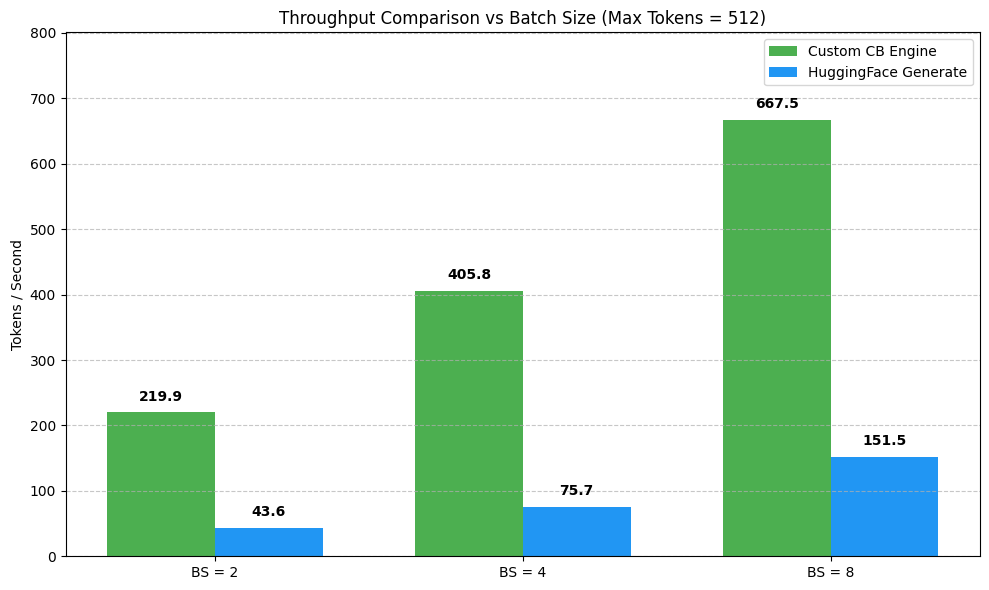

In [22]:
import numpy as np

# --- Plot the Benchmark Results ---
x = np.arange(len(batch_sizes))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, custom_results, width, label='Custom CB Engine', color='#4CAF50')
bars2 = plt.bar(x + width/2, hf_results, width, label='HuggingFace Generate', color='#2196F3')

plt.ylabel('Tokens / Second')
plt.title(f'Throughput Comparison vs Batch Size (Max Tokens = {max_gen_len})')
plt.xticks(x, [f'BS = {bs}' for bs in batch_sizes])
plt.legend()

max_val = max(max(custom_results), max(hf_results))
plt.ylim(0, max_val * 1.2)

# Add text labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max_val * 0.02),
                 f'{yval:.1f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
